# Buổi 4 · Perceptron phân loại cảnh báo nhập kho

**Case study thực tế:** từ thông tin lượng tồn kho, nhu cầu hàng ngày, thời gian giao hàng và các đặc điểm sản phẩm, xây một node nơ-ron cơ bản để dự đoán sản phẩm thuộc nhóm **rủi ro hết hàng cao** hay **an toàn / ổn định**. Node này có thể được ghép với các node khác trong một mạng nơ-ron lớn hơn.

## Tình huống

Một nhóm quản lý chuỗi cung ứng cần sàng lọc nhanh danh sách sản phẩm có nguy cơ trước khi chuyên viên xem chi tiết. Ta dùng ngưỡng **2.0** trên mức rủi ro để tạo nhãn học:

- `0` — An toàn / Ổn định: mức rủi ro dưới ngưỡng.
- `1` — Cảnh báo rủi ro cao: mức rủi ro từ ngưỡng trở lên.

Sau bài này, bạn có thể: chuẩn bị feature số và phân loại; chia train/test; huấn luyện Perceptron; đọc confusion matrix; giải thích `net = wᵀx + b`; và nhận ra data leakage.

> Dữ liệu trong repo là dữ liệu mô phỏng phục vụ học tập quản lý kho, không phải dữ liệu vận hành thực tế.

In [15]:
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ROOT = Path.cwd()
if not (ROOT / 'data' / 'processed_cleveland.csv').exists():
    ROOT = ROOT.parent

# Sửa lại tên file ở đây (bỏ số _2 ở cuối)
script_path = ROOT / 'bai-tap' / 'buoi4_perceptron_canh_bao_nhap_kho.py'
spec = spec_from_file_location('buoi4_stockout', script_path)
case = module_from_spec(spec)
sys.modules[spec.name] = case
assert spec.loader is not None
spec.loader.exec_module(case)

pd.set_option('display.max_columns', 20)

## 1. Đọc dữ liệu và tạo nhãn

CSV đã nằm trong `data/processed_cleveland.csv`, nên notebook chạy được khi không có Internet. Hãy đọc 5 dòng đầu và kiểm tra ý nghĩa từng cột trước khi huấn luyện.

In [16]:
THRESHOLD = 2.0
data = case.load_stockout_data(ROOT / 'data' / 'processed_cleveland.csv', threshold=THRESHOLD)
print(f'Số dòng: {len(data)} | Số cột: {data.shape[1]}')
data.head()

Số dòng: 297 | Số cột: 15


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,canh_bao_rui_ro
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


In [17]:
class_counts = (
    data[case.TARGET_COLUMN]
    .map(case.CLASS_NAMES)
    .value_counts()
    .rename_axis('nhãn')
    .to_frame('số mẫu')
)
class_counts['tỷ lệ'] = (class_counts['số mẫu'] / len(data)).round(3)
class_counts

,số mẫu,tỷ lệ
nhãn,,
An toàn / Ổn định,214,0.721
Cảnh báo rủi ro cao,83,0.279


### Điểm dừng · Vì sao không dùng cột mục tiêu gốc?

Nhãn được tạo trực tiếp từ cột `target`. Nếu đưa cột này vào đầu vào (features), mô hình sẽ nhìn thấy đáp án trước. Đây là **data leakage**: điểm số dự đoán sẽ rất đẹp nhưng không phản ánh khả năng suy luận thực tế của mô hình từ các đặc trưng khác.

Trước khi chạy ô tiếp theo, hãy ghi lại: nếu lỡ thêm cột `target` vào feature, accuracy sẽ có xu hướng tăng hay giảm? Vì sao?

In [18]:
assert not set(case.LEAKAGE_COLUMNS) & set(case.FEATURE_COLUMNS)
x_train, x_test, y_train, y_test = case.split_dataset(
    data, test_size=0.25, random_state=42
)
print('Feature:', case.FEATURE_COLUMNS)
print('Train:', x_train.shape, '| Test:', x_test.shape)
print('Tỷ lệ lớp rủi ro cao trong train/test:', round(y_train.mean(), 3), round(y_test.mean(), 3))

Feature: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Train: (222, 13) | Test: (75, 13)
Tỷ lệ lớp rủi ro cao trong train/test: 0.279 0.28


## 2. Huấn luyện một node Perceptron

Pipeline thực hiện ba việc: chuẩn hoá feature số, one-hot encoding feature phân loại, rồi đưa vector kết quả vào một Perceptron. Node tính `net = wᵀx + b`; nếu `net ≥ 0` thì dự đoán lớp 1. Đây vẫn là node cơ bản đã học — chỉ có nhiều feature thực tế hơn.

In [19]:
model = case.build_model(random_state=42, eta0=0.1)
model.fit(x_train, y_train)
predictions = model.predict(x_test)
net_scores = model.decision_function(x_test)

print('Đã huấn luyện xong.')
print('5 giá trị net đầu tiên:', net_scores[:5].round(3))
print('5 nhãn dự đoán đầu tiên:', predictions[:5])

Đã huấn luyện xong.
5 giá trị net đầu tiên: [-1.713 -0.897  0.551 -1.466 -0.792]
5 nhãn dự đoán đầu tiên: [0 0 1 0 0]


## 3. Đánh giá trên dữ liệu chưa thấy

Không chỉ nhìn accuracy. Với lớp `Cảnh báo rủi ro cao`, **precision** trả lời “các trường hợp bị gắn nhãn rủi ro cao đúng bao nhiêu?”, còn **recall** trả lời “mô hình tìm thấy bao nhiêu trường hợp thật sự thuộc lớp rủi ro cao?”.

In [20]:
report = pd.DataFrame(
    classification_report(
        y_test,
        predictions,
        labels=[0, 1],
        target_names=[case.CLASS_NAMES[0], case.CLASS_NAMES[1]],
        output_dict=True,
        zero_division=0,
    )
).transpose()
report.round(3)

,precision,recall,f1-score,support
An toàn / Ổn định,0.842,0.889,0.865,54.0
Cảnh báo rủi ro cao,0.667,0.571,0.615,21.0
accuracy,0.800,0.800,0.800,0.8
macro avg,0.754,0.730,0.740,75.0
weighted avg,0.793,0.800,0.795,75.0


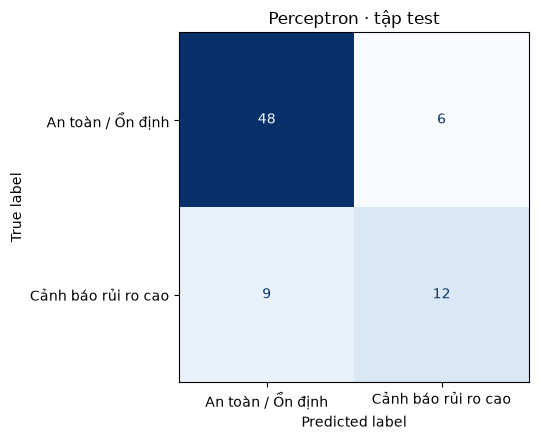

In [21]:
fig, ax = plt.subplots(figsize=(5.8, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    labels=[0, 1],
    display_labels=[case.CLASS_NAMES[0], case.CLASS_NAMES[1]],
    cmap='Blues',
    colorbar=False,
    ax=ax,
)
ax.set_title('Perceptron · tập test')
plt.tight_layout()
plt.show()

### Câu hỏi phân tích

1. Ghi số `TN`, `FP`, `FN`, `TP` từ ma trận.
2. Trong tình huống cảnh báo nhập kho, `FP` hay `FN` gây tốn kém chi phí hoặc rủi ro hơn?
3. Accuracy có đủ để kết luận mô hình tốt không? Liên hệ với tỷ lệ hai lớp.

## 4. Nối trọng số với công thức trên lớp

Trọng số dương kéo `net` về phía lớp `Cảnh báo rủi ro cao`; trọng số âm kéo về phía `An toàn / Ổn định`. Đây là **mối liên hệ trong bộ dữ liệu mô phỏng quản lý kho**, không phải kết luận nhân quả thực tế.

In [22]:
weights = case.feature_weight_table(model)
print('5 trọng số dương lớn nhất (kéo về rủi ro cao):')
display(weights.head(5))
print('5 trọng số âm lớn nhất về độ lớn (kéo về an toàn):')
display(weights.tail(5).sort_values('weight'))
print('Bias b =', round(float(model.named_steps['perceptron'].intercept_[0]), 3))

5 trọng số dương lớn nhất (kéo về rủi ro cao):


,feature,weight
0,thalach,0.414199
1,ca_2.0,0.400000
2,restecg_1.0,0.300000
3,ca_3.0,0.300000
4,oldpeak,0.274444


5 trọng số âm lớn nhất về độ lớn (kéo về an toàn):


,feature,weight
27,ca_0.0,-0.7
26,thal_3.0,-0.4
25,cp_1.0,-0.3
24,restecg_0.0,-0.3
23,exang_0.0,-0.2


Bias b = -0.0


In [23]:
errors = x_test.copy()
errors['giá trị thật'] = data.loc[x_test.index, case.TARGET_SOURCE_COLUMN]
errors['nhãn thật'] = y_test.to_numpy()
errors['dự đoán'] = predictions
errors['net'] = net_scores.round(3)
errors = errors[errors['nhãn thật'] != errors['dự đoán']]
print(f'Số mẫu dự đoán sai: {len(errors)}')
errors.sort_values('net')

Số mẫu dự đoán sai: 15


,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal,giá trị thật,nhãn thật,dự đoán,net
245,67.0,120.0,237.0,71.0,1.0,1.0,4.0,0.0,0.0,0.0,2.0,0.0,3.0,2,1,0,-3.123
79,58.0,150.0,270.0,111.0,0.8,1.0,4.0,0.0,2.0,1.0,1.0,0.0,7.0,3,1,0,-0.947
64,54.0,120.0,188.0,113.0,1.4,1.0,4.0,0.0,0.0,0.0,2.0,1.0,7.0,2,1,0,-0.910
223,53.0,123.0,282.0,95.0,2.0,1.0,4.0,0.0,0.0,1.0,2.0,2.0,7.0,3,1,0,-0.528
207,50.0,144.0,200.0,126.0,0.9,1.0,4.0,0.0,2.0,1.0,2.0,0.0,7.0,3,1,0,-0.496
136,70.0,145.0,174.0,125.0,2.6,1.0,4.0,0.0,0.0,1.0,3.0,0.0,7.0,4,1,0,-0.404
267,59.0,126.0,218.0,134.0,2.2,1.0,3.0,1.0,0.0,0.0,2.0,1.0,6.0,2,1,0,-0.202
284,61.0,148.0,203.0,161.0,0.0,1.0,4.0,0.0,0.0,0.0,1.0,1.0,7.0,2,1,0,-0.031
261,58.0,136.0,319.0,152.0,0.0,0.0,2.0,1.0,2.0,0.0,1.0,2.0,3.0,3,1,0,-0.012
177,56.0,132.0,184.0,105.0,2.1,1.0,4.0,0.0,2.0,1.0,2.0,1.0,6.0,1,0,1,0.001


## 5. Chạy thử trên mẫu dữ liệu mới

Hãy dự đoán bằng trực giác trước khi chạy. Chú ý `net` cho biết mẫu nằm phía nào của ranh giới; trị tuyệt đối càng gần 0 thì mẫu càng gần ranh giới quyết định.

In [24]:
import pandas as pd

new_samples = pd.DataFrame([
    {
        'age': 52, 'sex': 1, 'cp': 0, 'trestbps': 125, 'chol': 212,
        'fbs': 0, 'restecg': 1, 'thalach': 168, 'exang': 0, 'oldpeak': 1.0,
        'slope': 2, 'ca': 2, 'thal': 3,
    },
    {
        'age': 60, 'sex': 0, 'cp': 3, 'trestbps': 145, 'chol': 233,
        'fbs': 1, 'restecg': 0, 'thalach': 150, 'exang': 1, 'oldpeak': 2.3,
        'slope': 1, 'ca': 0, 'thal': 2,
    }
])

preds = model.predict(new_samples)
nets = model.decision_function(new_samples)

for i, (p, net) in enumerate(zip(preds, nets)):
    label_name = case.CLASS_NAMES[p]
    print(f"Mẫu {i+1}: Dự đoán = {label_name} (nhãn {p}) | net = {net:.3f}")

Mẫu 1: Dự đoán = Cảnh báo rủi ro cao (nhãn 1) | net = 0.206
Mẫu 2: Dự đoán = An toàn / Ổn định (nhãn 0) | net = -0.042


## 6. Bài tập nộp

### Phần A · Bắt buộc
1. Chạy toàn bộ notebook và báo cáo accuracy, precision, recall, F1 của lớp rủi ro cao.
2. Chọn hai mẫu dự đoán sai; giải thích bằng `net`, nhãn thật và đặc trưng đầu vào.
3. Tự tạo một mẫu dữ liệu kho mới hợp lệ, ghi dự đoán bằng tay rồi so với mô hình.
4. Giải thích trong 3–5 câu vì sao cột mục tiêu gốc không được đưa vào feature.

### Phần B · Thử nghiệm
Chạy lại với `threshold = 1.5`, `threshold = 2.0` và `threshold = 2.5`. Lập bảng gồm: ngưỡng, số mẫu mỗi lớp, accuracy, precision, recall và F1. Giải thích vì sao đổi cách tạo nhãn có thể làm đổi kết quả.

### Phần C · Nâng cao
Bỏ `StandardScaler` rồi huấn luyện lại cùng seed. So sánh kết quả và số epoch (`n_iter`). Từ đó giải thích vì sao chuẩn hoá quan trọng khi các đặc trưng số (như `age`, `trestbps`, `chol`, v.v.) có biên độ khác nhau.

In [25]:
# Khung chạy Phần B — khảo sát các ngưỡng phân loại cảnh báo rủi ro
experiment_rows = []
for threshold in [1.5, 2.0, 2.5]:
    experiment_data, result = case.run_experiment(
        threshold=threshold, test_size=0.25, random_state=42, eta0=0.1, use_scaler=True
    )
    counts = experiment_data[case.TARGET_COLUMN].value_counts()
    experiment_rows.append({
        'ngưỡng': threshold,
        'an toàn': int(counts.get(0, 0)),
        'rủi ro cao': int(counts.get(1, 0)),
        **{name: round(value, 3) for name, value in result.metrics.items()},
    })
pd.DataFrame(experiment_rows)

,ngưỡng,an toàn,rủi ro cao,accuracy,precision_lop_cao,recall_lop_cao,f1_lop_cao
0,1.5,214,83,0.8,0.667,0.571,0.615
1,2.0,214,83,0.8,0.667,0.571,0.615
2,2.5,249,48,0.8,0.333,0.250,0.286


## Checklist trước khi nộp

- [x] Restart kernel và Run All không lỗi.
- [x] Có câu trả lời cho ba câu hỏi về confusion matrix (TN, FP, FN, TP; chi phí rủi ro của FP/FN; đánh giá accuracy cùng tỷ lệ lớp).
- [x] Có phân tích hai mẫu dự đoán sai, không chỉ chép chỉ số.
- [x] Có một mẫu dữ liệu kho mới do chính bạn tạo.
- [x] Có bảng so sánh ba ngưỡng (`1.5`, `2.0`, `2.5`).
- [x] Không đưa cột mục tiêu gốc vào feature để tránh hiện tượng data leakage.